In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0


In [3]:
def create_model(learning_rate):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
fixed_lr_model = create_model(learning_rate=0.001)

history_fixed = fixed_lr_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=1
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9101 - loss: 0.3052 - val_accuracy: 0.9632 - val_loss: 0.1315
Epoch 2/20
269/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9659 - loss: 0.1183

In [5]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)

lr_decay_model = create_model(learning_rate=lr_schedule)

history_lr_decay = lr_decay_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9102 - loss: 0.3100 - val_accuracy: 0.9568 - val_loss: 0.1466
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9672 - loss: 0.1095 - val_accuracy: 0.9668 - val_loss: 0.1100
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9772 - loss: 0.0732 - val_accuracy: 0.9704 - val_loss: 0.0974
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9842 - loss: 0.0512 - val_accuracy: 0.9722 - val_loss: 0.0988
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9890 - loss: 0.0357 - val_accuracy: 0.9736 - val_loss: 0.0933
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9924 - loss: 0.0255 - val_accuracy: 0.9740 - val_loss: 0.0909
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9939 - loss: 0.0200 - val_accuracy: 0.9738 - val_loss: 0.0973
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9956 - loss: 0.0152 - val_accura

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

early_stop_model = create_model(learning_rate=0.001)

history_early = early_stop_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9112 - loss: 0.3102 - val_accuracy: 0.9520 - val_loss: 0.1577
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9670 - loss: 0.1126 - val_accuracy: 0.9674 - val_loss: 0.1095
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9769 - loss: 0.0756 - val_accuracy: 0.9704 - val_loss: 0.1021
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9840 - loss: 0.0532 - val_accuracy: 0.9730 - val_loss: 0.0956
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9877 - loss: 0.0408 - val_accuracy: 0.9722 - val_loss: 0.0962
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9902 - loss: 0.0311 - val_accuracy: 0.9747 - val_loss: 0.0937
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9927 - loss: 0.0227 - val_accuracy: 0.9755 - val_loss: 0.0976
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9918 - loss: 0.0247 - val_accur

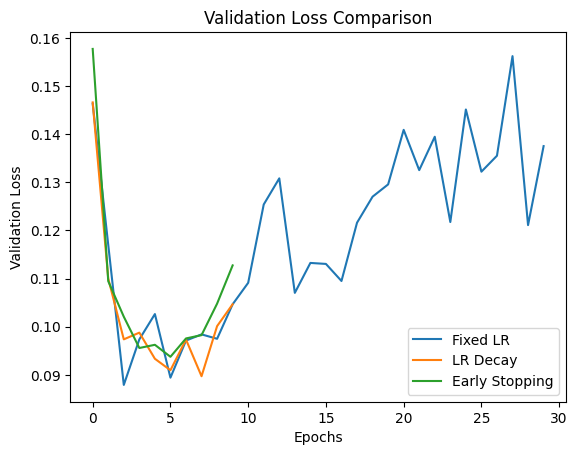

In [7]:
plt.figure()
plt.plot(history_fixed.history['val_loss'], label='Fixed LR')
plt.plot(history_lr_decay.history['val_loss'], label='LR Decay')
plt.plot(history_early.history['val_loss'], label='Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.show()


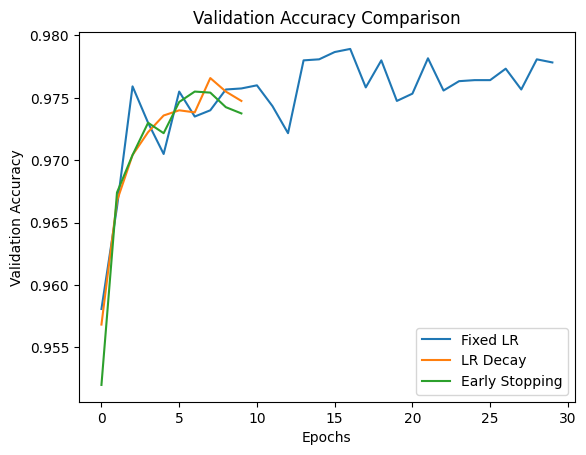

In [8]:
plt.figure()
plt.plot(history_fixed.history['val_accuracy'], label='Fixed LR')
plt.plot(history_lr_decay.history['val_accuracy'], label='LR Decay')
plt.plot(history_early.history['val_accuracy'], label='Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()


In [9]:
print("Fixed LR epochs:", len(history_fixed.history['loss']))
print("LR Decay epochs:", len(history_lr_decay.history['loss']))
print("Early Stopping epochs:", len(history_early.history['loss']))


Fixed LR epochs: 30
LR Decay epochs: 10
Early Stopping epochs: 10


In [10]:
test_loss, test_acc = early_stop_model.evaluate(x_test, y_test, verbose=0)

print("Best Model: Learning Rate + Early Stopping")
print("Test Accuracy:", test_acc)


Best Model: Learning Rate + Early Stopping
Test Accuracy: 0.9757999777793884
